# 🔍 Fraud Detection — Credit Card Transactions

End-to-end ML pipeline: **EDA → Feature Engineering → Modelling (Random Forest + XGBoost) → Threshold Tuning → SHAP Explainability → Deployment**

---

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import joblib

## Part 1 — Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv('creditcard.csv')
print(df.shape)

(284807, 31)


In [3]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [4]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
print(df['Class'].value_counts(normalize=True).mul(100).round(2))

Class
0    99.83
1     0.17
Name: proportion, dtype: float64


### EDA Findings

| Property | Value |
|---|---|
| Columns | 31 |
| Total transactions | 284,807 |
| Genuine (`Class = 0`) | 284,315 (99.83 %) |
| Fraud (`Class = 1`) | 492 (0.17 %) |

> ⚠️ **Severe class imbalance** — fraud is only 0.17 % of all transactions. Standard accuracy is misleading; we need PR-AUC as our primary metric.

---

## Part 2 — Feature Engineering

In [6]:
# We work on a copy data set
df2 = df.copy()

In [10]:
## Column - Time is in seconds based off the description
## Convert into hours 
df2['Hour'] = (df2['Time'] % 86400) // 3600

In [11]:
# Now check the column Amount
print(df2['Amount'].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


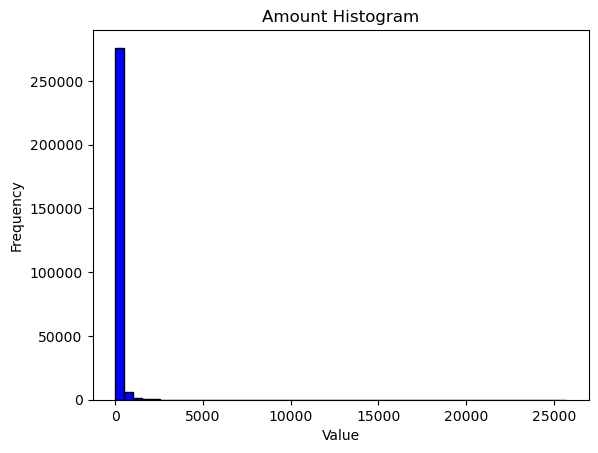

In [13]:
# Distribution of transaction amounts — heavily right-skewed
plt.hist(df2['Amount'], bins=50, color='blue', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Amount Distribution')
plt.show()


In [15]:
# Amount is heavily right-skewed — apply log transform to reduce skew
df2['Log_Amount'] = np.log1p(df2['Amount'])


In [16]:
## Drop the original columns
df2 = df2.drop(['Time', 'Amount'],axis=1)

In [17]:
df2[['Hour', 'Log_Amount']].describe().round(3)

,Hour,Log_Amount
count,284807.000,284807.000
mean,14.046,3.152
std,5.836,1.657
min,0.000,0.000
25%,10.000,1.887
50%,15.000,3.135
75%,19.000,4.359
max,23.000,10.154


### Feature Engineering Summary

| Feature | Transformation | Reason |
|---|---|---|
| `Time` | Converted to `Hour` (mod 86400 ÷ 3600) | Cyclical daily pattern |
| `Amount` | Log-transformed → `Log_Amount` | Heavily right-skewed distribution |
| Original `Time`, `Amount` | Dropped | Replaced by engineered features |

---

## Part 3 — Train / Test Split & Scaling

In [18]:
from sklearn.model_selection import train_test_split

In [31]:
X = df2.drop('Class', axis =1)
y = df2['Class']

In [32]:
## due to the imbalanced data set, need use stratify = y to ensure the 
## the train and test set keeps the same ratio of fraud 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
# Check X_train
print(f"X_train: {X_train.shape}")

X_train: (227845, 30)


In [34]:
# Check X_test
print(f"X_test: {X_test.shape}")

X_test: (56962, 30)


In [35]:
# Check y_train
print(f"Fraud in train: {y_train.sum()} ({y_train.mean()*100:.2f}%)")

Fraud in train: 394 (0.17%)


In [36]:
# Check y_test
print(f"Fraud in train: {y_test.sum()} ({y_train.mean()*100:.2f}%)")

Fraud in train: 98 (0.17%)


In [37]:
## From Kaggle data source V1 to V28 already scaled. 
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
# RobustScaler uses the median

In [38]:
X_train[['Log_Amount', 'Hour']] = scaler.fit_transform(X_train[['Log_Amount', 'Hour']])
X_test[['Log_Amount', 'Hour']]  = scaler.transform(X_test[['Log_Amount', 'Hour']])

In [40]:
## Check if scaling worked 
print(X_train['Log_Amount'].describe().round(3))
print(X_test['Hour'].describe().round(3))

count    227845.000
mean          0.007
std           0.670
min          -1.270
25%          -0.503
50%           0.000
75%           0.497
max           2.842
Name: Log_Amount, dtype: float64
count    56962.000
mean        -0.108
std          0.651
min         -1.667
25%         -0.556
50%          0.000
75%          0.444
max          0.889
Name: Hour, dtype: float64


### Handling Class Imbalance with SMOTE

With only 0.17 % fraud transactions, the model has too few examples to learn from. We use **SMOTE** (Synthetic Minority Oversampling Technique) to generate synthetic fraud samples.

> ⚠️ **Important:** SMOTE is applied **only to training data** — the test set is never touched.

| | Before SMOTE | After SMOTE |
|---|---|---|
| Genuine | 227,452 | 227,452 |
| Fraud | 394 | ~113,725 |
| Fraud ratio | 0.17 % | ~33 % |

---

In [41]:
from imblearn.over_sampling import SMOTE

In [42]:
smote = SMOTE(
    sampling_strategy = 0.5, 
    k_neighbors = 5,
    random_state = 42
)

In [43]:
# Apply ONLY to training data — never touch the test set
X_res, y_res = smote.fit_resample(X_train, y_train)

In [46]:
#non-fraud vs fraud
print((y_res == 0).sum())
print((y_res == 1).sum())

227451
113725


In [48]:
#non-fraud vs fraud
print((y_train == 0).sum())
print((y_train == 1).sum())

227451
394


In [50]:
## there are much more fraud sample to learn compare to the original data set
## Visualize the synthetic data 

## Filter X_trian, X_res by where y_train, y_res ==1 , index filtering
real_fraud = X_train[y_train == 1]['V14']
all_fraud_after = X_res[y_res == 1]['V14']

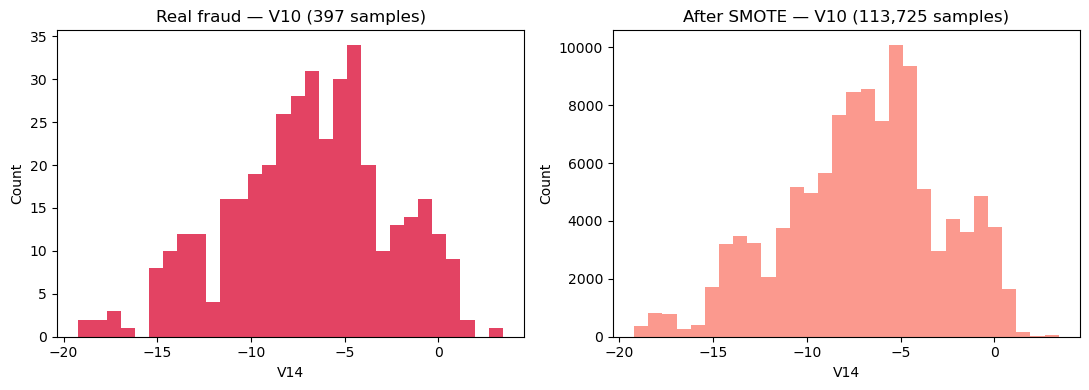

In [52]:
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(real_fraud, bins=30, color='crimson', alpha=0.8)
axes[0].set_title('Real fraud — V10 (397 samples)')
axes[0].set_xlabel('V14')
axes[0].set_ylabel('Count')

axes[1].hist(all_fraud_after, bins=30, color='salmon', alpha=0.8)
axes[1].set_title('After SMOTE — V10 (113,725 samples)')
axes[1].set_xlabel('V14')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# it follows the similar distribution after we applied SMOTE

## Part 4 — Model 1: Random Forest (Baseline)

In [53]:
from sklearn.ensemble import RandomForestClassifier


In [54]:
rfc = RandomForestClassifier(
    n_estimators=100,       # number of trees 
    max_depth=14,           # how deep each tree can grow
    class_weight='balanced',# automatically adjusts weights for imbalance
    min_samples_leaf=2,     # each leaf needs at least 2 samples
    n_jobs=-1,              # use all CPU cores — much faster
    random_state=42

)

In [55]:
print("Training Random Forest...")
t0 = time.time()
rfc.fit(X_res,y_res)
print(f"Training Completed in {time.time()-t0:.1f}s")

Training Random Forest...
Training Completed in 20.1s


In [56]:
rfc_predicts = rfc.predict(X_test)

In [57]:
# Get probability for each class
rfc_p = rfc.predict_proba(X_test)[:,1]

In [58]:
print(rfc_p.round(3))

[0.001 0.007 0.025 ... 0.003 0.001 0.022]


In [59]:
print(f"\nTransactions flagged as fraud: {rfc_predicts.sum()}")
print(f"Actual frauds in test set:     {y_test.sum()}")


Transactions flagged as fraud: 135
Actual frauds in test set:     98


### Random Forest — Model Evaluation

In [60]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, roc_auc_score
)


In [61]:
print(
    classification_report(
    y_test, rfc_predicts,
    target_names=['non-Fraud', 'Fraud']
    )
)

              precision    recall  f1-score   support

   non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.61      0.85      0.71        98

    accuracy                           1.00     56962
   macro avg       0.81      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [63]:
# --- Key metrics ---
# PR_AUC is more important for our objective , imbalanced data
pr_auc = average_precision_score(y_test, rfc_p)
roc_auc = roc_auc_score(y_test, rfc_p)
print(f"PR-AUC  (main metric): {pr_auc:.4f}")
print(f"ROC-AUC (reference):   {roc_auc:.4f}")

PR-AUC  (main metric): 0.8258
ROC-AUC (reference):   0.9797


In [64]:
# Confusion matrix — see exactly where the model makes mistakes
cm = confusion_matrix(y_test, rfc_predicts)
tn, fp, fn, tp = cm.ravel()

In [65]:
print(f"\nConfusion Matrix:")
print(f"  True Positive  (caught fraud):   {tp:4d}  ← we want this HIGH")
print(f"  False Negative (missed fraud):   {fn:4d}  ← we want this LOW")
print(f"  False Positive (false alarm):    {fp:4d}")
print(f"  True Negative  (correct clear):  {tn:4d}")


Confusion Matrix:
  True Positive  (caught fraud):     83  ← we want this HIGH
  False Negative (missed fraud):     15  ← we want this LOW
  False Positive (false alarm):      52
  True Negative  (correct clear):  56812


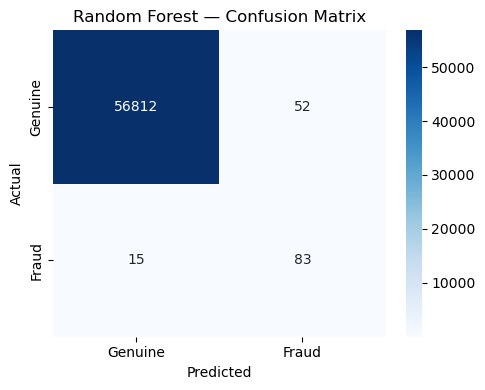

In [68]:
# Visualise the matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Fraud'],
            yticklabels=['Genuine', 'Fraud'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

### Random Forest — Feature Importance

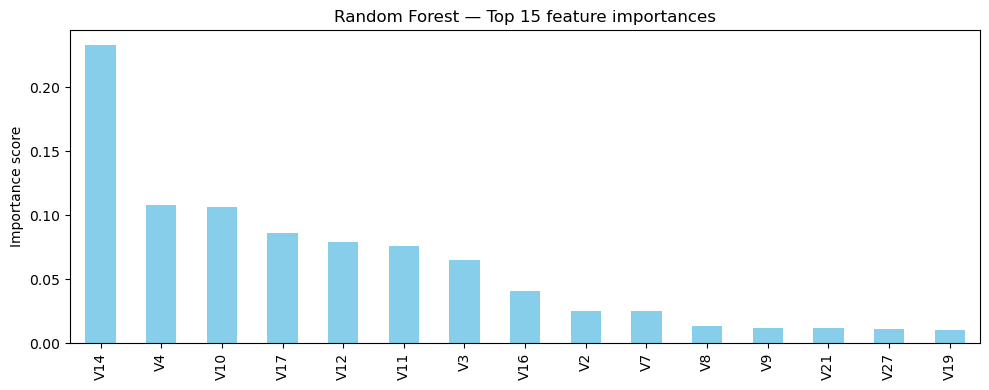


Top 5 most important features:
V14    0.2329
V4     0.1083
V10    0.1065
V17    0.0858
V12    0.0792
dtype: float64


In [70]:
# Random Forest gives free feature importance scores
importances = pd.Series(
    rfc.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot top 15 features
importances.head(15).plot(
    kind='bar',
    figsize=(10, 4),
    color='skyblue',
    title='Random Forest — Top 15 feature importances'
)
plt.ylabel('Importance score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.head(5).round(4))

In [73]:
# Save this baseline score 
baseline_scores = {
    'model':   'Random Forest',
    'pr_auc':  round(pr_auc, 4),
    'roc_auc': round(roc_auc, 4),
    'recall':  round(tp / (tp + fn), 4),   # how many frauds caught
    'precision': round(tp / (tp + fp), 4)  # how many flags were real fraud
}

print("\n=== Baseline to beat ===")
for x, y in baseline_scores.items():
    print(f"  {x:12s}: {y}")


=== Baseline to beat ===
  model       : Random Forest
  pr_auc      : 0.8258
  roc_auc     : 0.9797
  recall      : 0.8469
  precision   : 0.6148


## Part 5 — Model 2: XGBoost

In [74]:
# scale_pos_weight
# This is the single most important parameter for fraud detection
# It tells XGBoost how much more to penalise missing a fraud
# vs flagging a genuine transaction

genuine_count = (y_train == 0).sum()   # 227,452
fraud_count   = (y_train == 1).sum()   #     393

scale_pos_weight = genuine_count / fraud_count

print(f"Genuine: {genuine_count:,}")
print(f"Fraud:   {fraud_count:,}")
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

Genuine: 227,451
Fraud:   394
scale_pos_weight = 577.3


In [75]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=1500,            # max trees to build (early stopping will cut this)
    max_depth=6,                 # depth of each tree
    learning_rate=0.05,          # how much each tree contributes
    scale_pos_weight=scale_pos_weight,  # 579 — penalise missing fraud heavily
    subsample=0.8,               # each tree sees 80% of rows
    colsample_bytree=0.8,        # each tree sees 80% of features
    min_child_weight=5,          # minimum samples needed to make a split
    gamma=1,                     # minimum loss reduction to make a split
    reg_alpha=0.1,               # L1 regularisation — reduces overfitting
    reg_lambda=1,                # L2 regularisation — reduces overfitting
    eval_metric='aucpr',         # monitor PR-AUC during training
    early_stopping_rounds=100,    # stop if no improvement for 100 rounds
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train, y_train,            # training data (no SMOTE needed — using scale_pos_weight)
    eval_set=[(X_test, y_test)], # monitor performance on test set each round
    verbose=100                 # print progress every 50 rounds
)

print(f"\nBest round: {xgb.best_iteration}")
print(f"Best PR-AUC: {xgb.best_score:.4f}")

[0]	validation_0-aucpr:0.62021
[100]	validation_0-aucpr:0.80781
[200]	validation_0-aucpr:0.86231
[300]	validation_0-aucpr:0.87517
[400]	validation_0-aucpr:0.87904
[500]	validation_0-aucpr:0.87951
[600]	validation_0-aucpr:0.87998
[700]	validation_0-aucpr:0.87958
[731]	validation_0-aucpr:0.87989

Best round: 631
Best PR-AUC: 0.8806


In [76]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              average_precision_score, roc_auc_score)

# Predictions
xgb_preds = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# Metrics
pr_auc  = average_precision_score(y_test, xgb_proba)
roc_auc = roc_auc_score(y_test, xgb_proba)

print("=== XGBoost Evaluation ===\n")
print(classification_report(y_test, xgb_preds,
      target_names=['Genuine', 'Fraud']))
print(f"PR-AUC  : {pr_auc:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")

# --- Confusion matrix ---
tn, fp, fn, tp = confusion_matrix(y_test, xgb_preds).ravel()
print(f"\nConfusion Matrix:")
print(f"  True Positive  (caught fraud):  {tp:4d}")
print(f"  False Negative (missed fraud):  {fn:4d}")
print(f"  False Positive (false alarm):   {fp:4d}")
print(f"  True Negative  (correct clear): {tn:4d}")

=== XGBoost Evaluation ===

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC  : 0.8808
ROC-AUC : 0.9761

Confusion Matrix:
  True Positive  (caught fraud):    82
  False Negative (missed fraud):    16
  False Positive (false alarm):     15
  True Negative  (correct clear): 56849


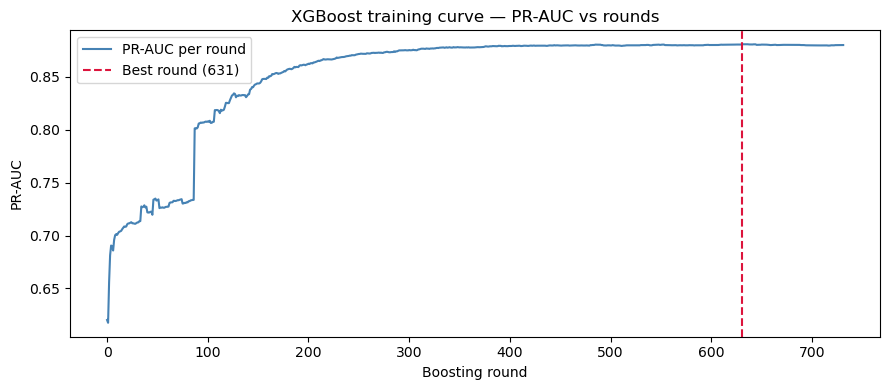

In [78]:
# Extract PR-AUC score at each boosting round
results_dict = xgb.evals_result()
aucpr_scores = results_dict['validation_0']['aucpr']

plt.figure(figsize=(9, 4))
plt.plot(aucpr_scores, color='steelblue', lw=1.5, label='PR-AUC per round')
plt.axvline(xgb.best_iteration, color='crimson', linestyle='--',
            label=f'Best round ({xgb.best_iteration})')
plt.xlabel('Boosting round')
plt.ylabel('PR-AUC')
plt.title('XGBoost training curve — PR-AUC vs rounds')
plt.legend()
plt.tight_layout()
plt.show()

## Part 6 — Threshold Tuning

XGBoost outputs a **probability** for each transaction. The default threshold (0.5) isn't optimal for imbalanced fraud data. We scan all possible thresholds to find the one that maximises F1 score.

In [82]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_proba = xgb.predict_proba(X_test)[:, 1]

print("Sample probabilities:")
print(y_proba[:10].round(4))

print(f"\nMin probability:  {y_proba.min():.4f}")
print(f"Max probability:  {y_proba.max():.4f}")
print(f"Mean probability: {y_proba.mean():.4f}")

Sample probabilities:
[0.     0.     0.     0.     0.0002 0.     0.     0.     0.     0.    ]

Min probability:  0.0000
Max probability:  1.0000
Mean probability: 0.0019


In [83]:
# precision_recall_curve tests every possible threshold
# and returns precision + recall at each one
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

print(f"Number of thresholds tested: {len(thresholds)}")
print(f"\nSample threshold values:")
print(thresholds[:5].round(4))   # very low thresholds
print(thresholds[-5:].round(4))  # very high thresholds

# precision and recall have one more value than thresholds
# the last value is always precision=1, recall=0 (edge case)
print(f"\nprecision array length: {len(precision)}")
print(f"recall array length:    {len(recall)}")
print(f"thresholds length:      {len(thresholds)}")

Number of thresholds tested: 56345

Sample threshold values:
[0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1.]

precision array length: 56346
recall array length:    56346
thresholds length:      56345


In [84]:
# Optimized the F1 Score
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

best_idx    = f1_scores.argmax()
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f"Best threshold (F1):  {best_thresh:.4f}")
print(f"Precision at best:    {precision[best_idx]:.4f}")
print(f"Recall at best:       {recall[best_idx]:.4f}")
print(f"F1 at best:           {best_f1:.4f}")

Best threshold (F1):  0.8641
Precision at best:    0.9111
Recall at best:       0.8367
F1 at best:           0.8723


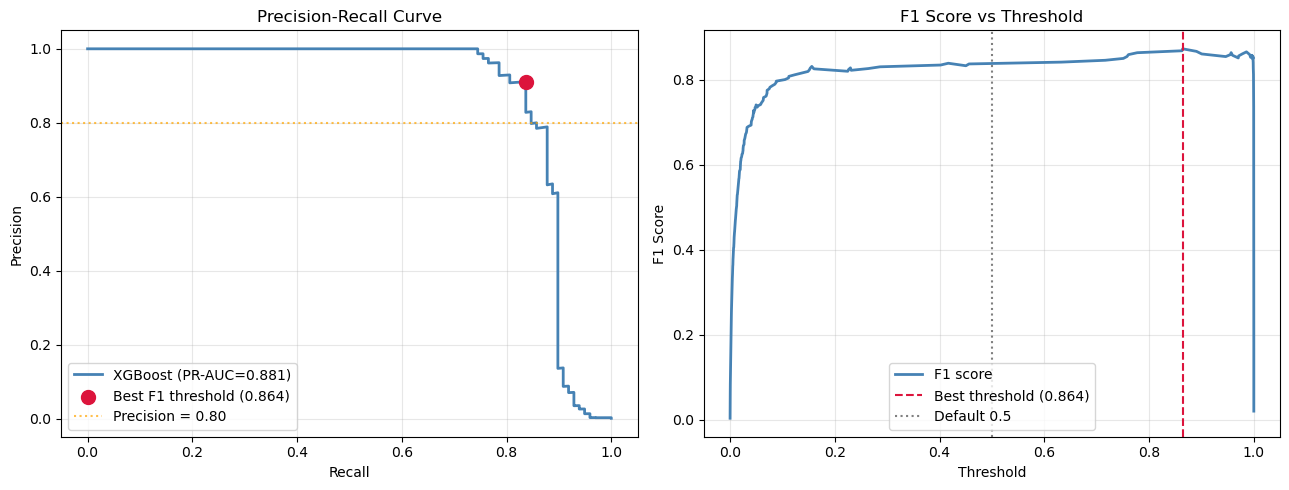

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Precision-Recall curve ---
axes[0].plot(recall, precision, lw=2, color='steelblue',
             label=f'XGBoost (PR-AUC={average_precision_score(y_test, y_proba):.3f})')
axes[0].scatter(recall[best_idx], precision[best_idx],
                color='crimson', zorder=5, s=100,
                label=f'Best F1 threshold ({best_thresh:.3f})')
axes[0].axhline(0.80, color='orange', linestyle=':', alpha=0.7, label='Precision = 0.80')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: F1 score across thresholds ---
axes[1].plot(thresholds, f1_scores, lw=2, color='steelblue', label='F1 score')
axes[1].axvline(best_thresh, color='crimson', linestyle='--',
                label=f'Best threshold ({best_thresh:.3f})')
axes[1].axvline(0.5, color='grey', linestyle=':', label='Default 0.5')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Threshold Decision

Choose the threshold based on **business priority**:

| Priority | Strategy |
|---|---|
| Catch every fraud | Lower threshold (higher recall, more false alarms) |
| Minimise false alarms | Higher threshold (lower recall, fewer alerts) |
| Balanced | **Best F1 threshold** ← *used here* |

In [90]:
THRESHOLD = best_thresh 

y_pred_final = (y_proba >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

In [92]:
print(f"=== Final Results @ threshold = {THRESHOLD:.4f} ===\n")
print(f"Frauds in test set:      {y_test.sum()}")
print(f"Caught (True Positive):  {tp}  ({tp/y_test.sum()*100:.1f}% of all fraud)")
print(f"Missed (False Negative): {fn}  ({fn/y_test.sum()*100:.1f}% of all fraud)")
print(f"False alarms (FP):       {fp}")
print(f"Correct clears (TN):     {tn}")
print("We reduce the FP")

=== Final Results @ threshold = 0.8641 ===

Frauds in test set:      98
Caught (True Positive):  82  (83.7% of all fraud)
Missed (False Negative): 16  (16.3% of all fraud)
False alarms (FP):       8
Correct clears (TN):     56856
We reduce the FP


## Part 7 — Business Cost Estimate

Translate model performance into dollar impact using simple assumptions:
- Missed fraud (FN) costs **$200** per case
- False alarm (FP) costs **$35** per review

In [93]:
# let's assume fraud cost $200 each case , false positive cost $35
FRAUD_COST  = 200   # avg $ loss per missed fraud
REVIEW_COST = 35    # $ cost to review a false alarm
total_cost  = fn * FRAUD_COST + fp * REVIEW_COST

In [94]:
print(f"\nEstimated business cost: ${total_cost:,}")
print(f"  Missed fraud cost:  {fn} × ${FRAUD_COST} = ${fn*FRAUD_COST:,}")
print(f"  False alarm cost:   {fp} × ${REVIEW_COST}  = ${fp*REVIEW_COST:,}")


Estimated business cost: $3,480
  Missed fraud cost:  16 × $200 = $3,200
  False alarm cost:   8 × $35  = $280


## Part 8 — Model Explainability with SHAP

[SHAP (SHapley Additive exPlanations)](https://shap.readthedocs.io/) assigns each feature a contribution score for every prediction, showing *why* the model flagged a transaction.

In [95]:
import shap

explainer = shap.TreeExplainer(xgb)

In [96]:
base_value = float(np.array(explainer.expected_value).flat[0])

print("Explainer created successfully")
print(f"Expected base value: {base_value:.6f}")

Explainer created successfully
Expected base value: 0.127457


In [98]:
# sample 5000 transactions 
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=5000, replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)
y_sample   = y_test.iloc[sample_idx].reset_index(drop=True)

print(f"Sample size:     {len(X_sample)}")
print(f"Fraud in sample: {y_sample.sum()}")

Sample size:     5000
Fraud in sample: 5


In [115]:
shap_explanation_obj = explainer(X_sample)

print(f"\nType returned: {type(shap_explanation_obj)}")
print(f"Shape:         {shap_explanation_obj.shape}")
shap_values = shap_explanation_obj.values


Type returned: <class 'shap._explanation.Explanation'>
Shape:         (5000, 30)


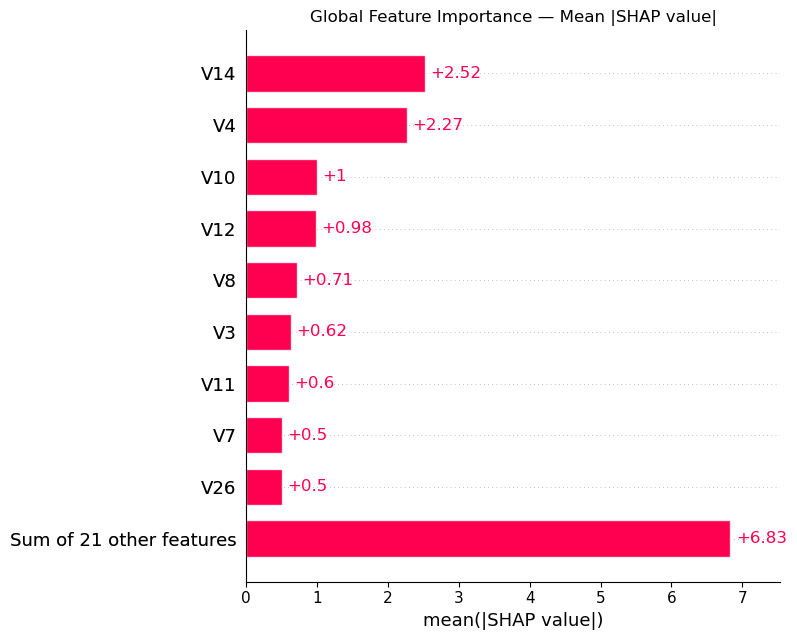

In [106]:
shap.plots.bar(shap_explanation_obj, max_display=10, show=False)
plt.title('Global Feature Importance — Mean |SHAP value|')
plt.tight_layout()
plt.show()

In [101]:
# Find an example in the sample 
fraud_positions   = np.where(y_sample.values == 1)[0]
genuine_positions = np.where(y_sample.values == 0)[0]

fraud_pos   = fraud_positions[0]
genuine_pos = genuine_positions[0]

fraud_prob   = float(xgb.predict_proba(X_sample.iloc[[fraud_pos]])[:, 1][0])
genuine_prob = float(xgb.predict_proba(X_sample.iloc[[genuine_pos]])[:, 1][0])

In [104]:
print(f"Fraud transaction   — prob: {fraud_prob:.4f}")
print(f"Genuine transaction — prob: {genuine_prob:.4f}")

Fraud transaction   — prob: 1.0000
Genuine transaction — prob: 0.0000


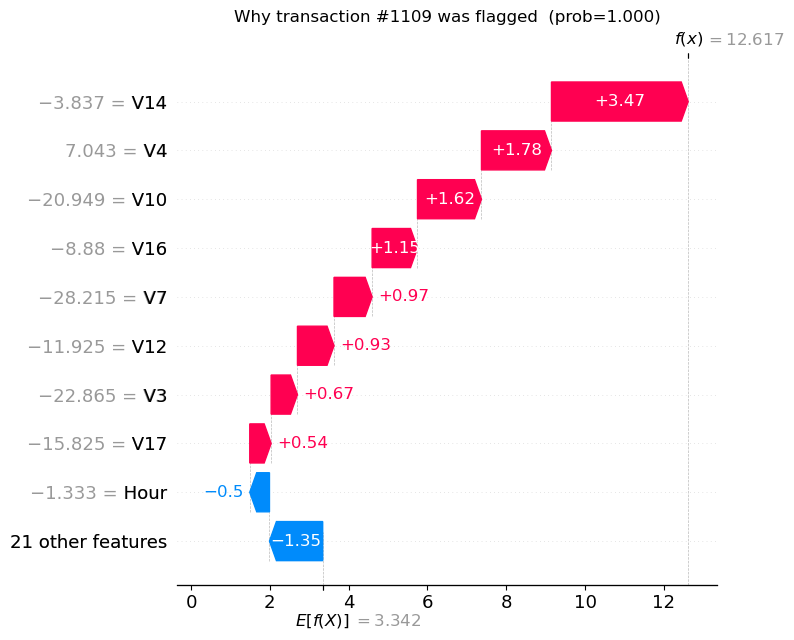

In [105]:
# shap_explanation_obj[idx] gives one transaction's explanation
shap.plots.waterfall(shap_explanation_obj[fraud_pos], show=False)
plt.title(f'Why transaction #{fraud_pos} was flagged  (prob={fraud_prob:.3f})')
plt.tight_layout()
plt.show()

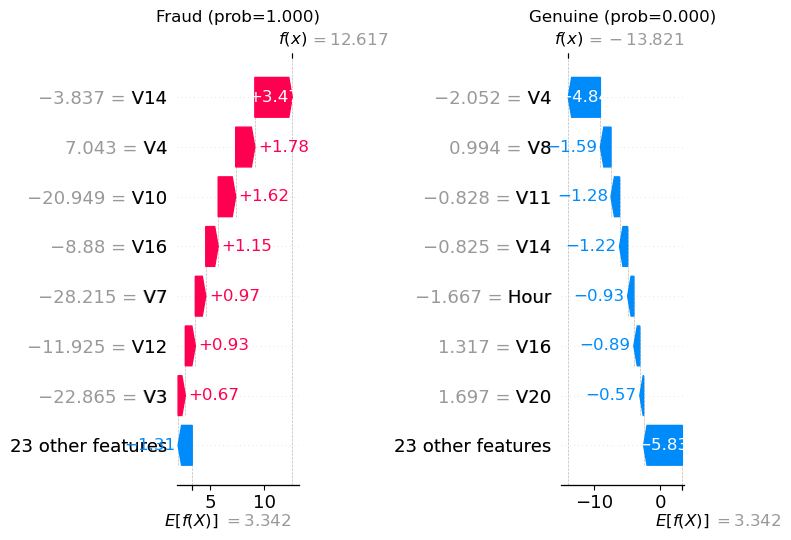

In [107]:
## Compare the genuine and Fraud transactions 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud waterfall
plt.sca(axes[0])
shap.plots.waterfall(
    shap_explanation_obj[fraud_pos],
    max_display=8,
    show=False
)
axes[0].set_title(f'Fraud (prob={fraud_prob:.3f})')

# Genuine waterfall
plt.sca(axes[1])
shap.plots.waterfall(
    shap_explanation_obj[genuine_pos],
    max_display=8,
    show=False
)
axes[1].set_title(f'Genuine (prob={genuine_prob:.3f})')

plt.tight_layout()
plt.show()

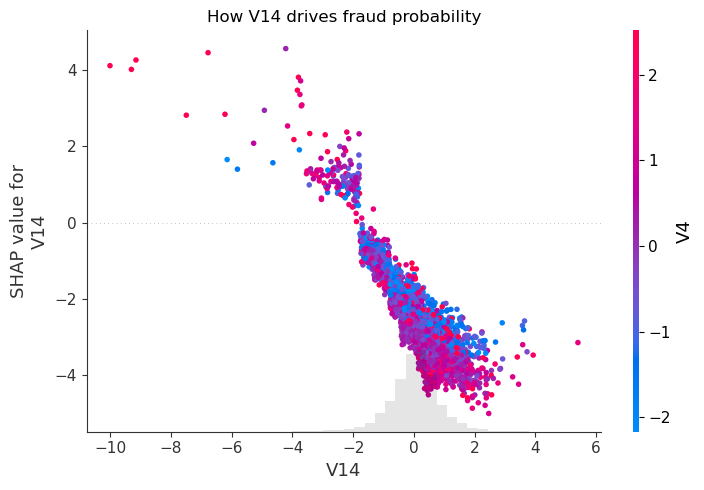

In [113]:
# Check how V14 drives the fraud probabiity, most important feature in our data
shap.plots.scatter(
    shap_explanation_obj[:, 'V14'],   # select V14 column
    color=shap_explanation_obj[:, 'V4'],  # colour by V17
    show=False
)
plt.title('How V14 drives fraud probability')
plt.tight_layout()
plt.show()

In [116]:
def explain_transaction(idx, top_n=5):
    prob  = float(xgb.predict_proba(X_sample.iloc[[idx]])[:, 1][0])
    label = int(y_sample.iloc[idx])
    sv    = shap_values[idx]           
    feats = X_sample.columns.tolist()

    sorted_idx = np.argsort(np.abs(sv))[::-1]

    print(f"=== Transaction #{idx} ===")
    print(f"True label:  {'FRAUD' if label==1 else 'Genuine'}")
    print(f"Fraud prob:  {prob:.4f}  ({prob*100:.1f}%)")
    print(f"Decision:    {'FLAGGED' if prob >= THRESHOLD else 'CLEARED'}")
    print(f"Base value:  {base_value:.6f}")
    print(f"\nTop {top_n} contributing features:")
    print(f"{'Feature':<18} {'Value':>10} {'SHAP':>10}  Direction")
    print("-" * 55)

    for i in sorted_idx[:top_n]:
        direction = "→ fraud" if sv[i] > 0 else "→ genuine"
        print(f"{feats[i]:<18} "
              f"{X_sample.iloc[idx, i]:>10.3f} "
              f"{sv[i]:>+10.4f}  {direction}")

    print(f"\nSum check:   {base_value + sv.sum():.4f} ≈ {prob:.4f}")

# Run on fraud and genuine
print("\n"); explain_transaction(fraud_pos)
print("\n"); explain_transaction(genuine_pos)



=== Transaction #1109 ===
True label:  FRAUD
Fraud prob:  1.0000  (100.0%)
Decision:    FLAGGED
Base value:  0.127457

Top 5 contributing features:
Feature                 Value       SHAP  Direction
-------------------------------------------------------
V14                    -3.837    +3.4697  → fraud
V4                      7.043    +1.7762  → fraud
V10                   -20.949    +1.6234  → fraud
V16                    -8.880    +1.1513  → fraud
V7                    -28.215    +0.9671  → fraud

Sum check:   9.4027 ≈ 1.0000


=== Transaction #0 ===
True label:  Genuine
Fraud prob:  0.0000  (0.0%)
Decision:    CLEARED
Base value:  0.127457

Top 5 contributing features:
Feature                 Value       SHAP  Direction
-------------------------------------------------------
V4                     -2.052    -4.8382  → genuine
V8                      0.994    -1.5926  → genuine
V11                    -0.828    -1.2828  → genuine
V14                    -0.825    -1.2218  → genuine

In [118]:
# Save the trained XGBoost model
joblib.dump(xgb, 'fraud_model.joblib')

# Save the scaler (fitted in Part 3)
joblib.dump(scaler, 'scaler.joblib')

# Save the threshold and metadata
config = {
    'threshold':         float(THRESHOLD),
    'base_value':        float(base_value),
    'scale_pos_weight':  float(scale_pos_weight),
    'feature_names':     X_train.columns.tolist(),
    'model_pr_auc':      0.8804,
    'xgb_version':       '3.0.1',
    'shap_version':      '0.51.0'
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved files:")
print("  fraud_model.joblib  — XGBoost model")
print("  scaler.joblib       — RobustScaler")
print("  model_config.json   — threshold + metadata")


Saved files:
  fraud_model.joblib  — XGBoost model
  scaler.joblib       — RobustScaler
  model_config.json   — threshold + metadata
